In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error

# PyTorch Forecasting + Lightning
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer, TorchNormalizer
from pytorch_forecasting.metrics import SMAPE, RMSE, MAE, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.callbacks.progress import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")   # utilise RTX Tensor Cores
    print("float32 matmul precision set to 'medium'")

# import pytorch_forecasting.models.base._base_model as _bm
# _orig_plot = _bm.BaseModel.log_prediction
#
# def _patched_log_prediction(self, x, out, batch_idx, **kwargs):
#     # cast any bf16 tensors in out to float32 before matplotlib touches them
#     out = {
#         k: v.float() if isinstance(v, torch.Tensor) and v.dtype == torch.bfloat16 else v
#         for k, v in out.items()
#     }
#     return _orig_plot(self, x, out, batch_idx, **kwargs)
#
# _bm.BaseModel.log_prediction = _patched_log_prediction

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [3]:
# ==============================================================================
# Cell 2 – Memory-Optimization Helpers  (unchanged from original script)
# ==============================================================================
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        if np.iinfo(np.int8).min <= min_val <= max_val <= np.iinfo(np.int8).max:
            return "int8"
        if np.iinfo(np.int16).min <= min_val <= max_val <= np.iinfo(np.int16).max:
            return "int16"
        if np.iinfo(np.int32).min <= min_val <= max_val <= np.iinfo(np.int32).max:
            return "int32"
        return "int64"
    else:
        if 0 <= min_val <= max_val <= np.iinfo(np.uint8).max:
            return "uint8"
        if 0 <= min_val <= max_val <= np.iinfo(np.uint16).max:
            return "uint16"
        if 0 <= min_val <= max_val <= np.iinfo(np.uint32).max:
            return "uint32"
        return "uint64"


def optimize_df_for_memory(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Converts columns to smaller dtypes.
    For low-decimal float columns, stores scaled integers if that beats float32.
    Returns:
        optimized_df
        metadata dict with scaling info
    """
    meta = {}

    for col in df.columns:
        s = df[col]

        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}):
            if col == "Група":
                df[col] = s.astype("bool")
                meta[col] = {"stored_as": "bool", "scale": 1}
                continue

        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue

        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue

            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()

            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn = int(np.nanmin(scaled))
                mx = int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                int_bytes = np.dtype(int_dtype).itemsize
                float32_bytes = np.dtype("float32").itemsize
                if int_bytes < float32_bytes:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                else:
                    df[col] = s.astype("float32")
                    meta[col] = {"stored_as": "float32", "scale": 1}
            else:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}

    return df, meta

In [4]:
# ==============================================================================
# Cell 3 – Metric Helpers  (unchanged from original script)
# ==============================================================================
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────────
TRAIN_PATH = "data/silver_money_calc/train.parquet"
VAL_PATH   = "data/silver_money_calc/val.parquet"
TEST_PATH  = "data/silver_money_calc/test.parquet"
TEST2_PATH  = "data/no_y_col/with_weather_v2.parquet"

# ── Target ─────────────────────────────────────────────────────────────────────
Y_COL = 'Sum of кВт'

GROUP_COL = "EIC-код_cat"

In [6]:
FUTURE_REALS = [
    'temperature_2m', 'apparent_temperature',
       'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain',
       'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'surface_pressure', 'wind_speed_10m',
       'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation',
       'diffuse_radiation', 'direct_normal_irradiance'
]
weather_cols_to_drop = ['apparent_temperature', 'rain',
       'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'surface_pressure', 'wind_direction_10m', 'wind_gusts_10m', 'diffuse_radiation', 'direct_normal_irradiance']

# ── Numerical real-valued covariates NOT known at forecast time ─────────────────
PAST_REALS = [
    # 'Ціна розподілу ЕЕ', 'Ціна ЕЕ', "Money_spent"
]   # add any columns that are only available historically

# ── Static numerical covariates (one value per station, time-invariant) ─────────
STATIC_REALS = [
    'Широта', 'Довгота',
]

# ── Categorical time-varying known covariates ───────────────────────────────────
# Calendar categoricals — always known in the future
TIME_VARYING_KNOWN_CATS = [
    # "Year_cat",
    "Month_cat", "Day_cat", "Hour_cat", "day_of_week_cat", "season_cat"
]  # created in Cell 5

# ── Static categoricals ─────────────────────────────────────────────────────────
# One-hot encoded columns will be collapsed back to a single categorical.
# Any remaining OHE groups (Тип, Область, …) are handled similarly.
STATIC_CATS = ['EIC-код_cat', 'Група_cat', 'АЗС_cat', 'Тип_cat', 'Область_cat', 'ОСР код_cat', 'ОСР опис_cat']

In [7]:
# ── Forecasting horizon & encoder length ───────────────────────────────────────
# Predict this many hours ahead
MAX_PREDICTION_LENGTH = 36         # 24 h forecast
MAX_ENCODER_LENGTH    = 36    # look-back window: 7 days

# ── Training hyper-parameters ──────────────────────────────────────────────────
BATCH_SIZE    = 1024 * 2
MAX_EPOCHS    = 50
LEARNING_RATE = 3e-3
HIDDEN_SIZE            = 32   # was 64
ATTENTION_HEAD_SIZE    = 2    # was 4
HIDDEN_CONTINUOUS_SIZE = 16   # was 32
DROPOUT       = 0.1

In [8]:
def build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    PyTorch Forecasting requires a monotonically increasing integer time_idx
    that is *shared* across all groups (think of it as the global hour counter).
    """
    # Global hourly index starting from the minimum timestamp in the dataset

    df['datetime'] = pd.to_datetime(df['datetime'])
    min_dt = df["datetime"].min()
    try:
        if GLOBAL_MIN_DT:
            df["time_idx"] = ((df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600).astype(int)
    except:
        GLOBAL_MIN_DT = df["datetime"].min()
        df["time_idx"] = ((df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600).astype(int)
    return df

def add_cat_helpers(df: pd.DataFrame) -> pd.DataFrame:
    """Create string categoricals from datetime for PyTorch Forecasting."""

    # ensure datetime column is in datetime format
    df['datetime'] = pd.to_datetime(df['datetime'])

    # basic time components
    # df['Year_cat'] = df['datetime'].dt.year
    df['Month_cat'] = df['datetime'].dt.month.astype(str)
    df['Day_cat'] = df['datetime'].dt.day.astype(str)
    df['Hour_cat'] = df['datetime'].dt.hour.astype(str)

    # day of week (0=Monday)
    df['day_of_week_cat'] = df['datetime'].dt.dayofweek.astype(str)

    # season mapping
    def get_season(month):
        if month in [12, 1, 2]:
            return 'winter'
        elif month in [3, 4, 5]:
            return 'spring'
        elif month in [6, 7, 8]:
            return 'summer'
        else:
            return 'autumn'

    df['season_cat'] = df['datetime'].dt.month.map(get_season)

    return df

def load_and_prepare(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path).reset_index(drop=True)

    df = df[df["datetime"] >= "2024-06-30"].reset_index(drop=True)

    df.columns = df.columns.str.replace('.', '_', regex=False)
    df, _ = optimize_df_for_memory(df)

    # Cast compressed ints back to float32 for PTF
    for col in df.select_dtypes(
        include=["int8","int16","int32","uint8","uint16","uint32"]
    ).columns:
        if col not in ["Year","Month","Day","Hour","day_of_week","season_number"]:
            df[col] = df[col].astype("float32")

    df = build_time_index(df)
    df = add_cat_helpers(df)
    for col in df.columns:
        if col.endswith("_cat"):
            df[col] = df[col].astype(str)
    try:
        df[Y_COL] = df[Y_COL].astype("float32")
    except:
        df[Y_COL] = 0
        print("no y column")
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    try:
        df.drop(columns=['Ціна розподілу ЕЕ', 'Ціна ЕЕ', "Money_spent"], inplace=True)
    except:
        print("no prices columns")

    df.drop(columns=weather_cols_to_drop, inplace=True)
    return df

In [9]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH)

print(f"train range: {train['datetime'].min()}, {train['datetime'].max()}")

# Compute global min datetime from train so val/test share the same time_idx origin
# GLOBAL_MIN_DT = train["datetime"].min()

print("Loading val   …")
val = load_and_prepare(VAL_PATH)

print("Loading test  …")
test = load_and_prepare(TEST_PATH)

print("Loading test2  …")
test2 = load_and_prepare(TEST2_PATH)
# test2['Ціна розподілу ЕЕ'] = 0
# test2['Ціна ЕЕ'] = 0
# test2['Money_spent'] = 0

Loading train …
train range: 2024-06-30 00:00:00+03:00, 2025-06-30 23:00:00+03:00
Loading val   …
Loading test  …
Loading test2  …
no y column
no prices columns


In [10]:
station_stats = (
    train.groupby(GROUP_COL)
    .agg(
        rows=(Y_COL, "count"),
        hours_span=("time_idx", lambda x: x.max() - x.min()),
        missing_pct=("time_idx", lambda x: 1 - len(x) / (x.max() - x.min() + 1)),
        target_mean=(Y_COL, "mean"),
        target_std=(Y_COL, "std"),
        target_zeros=(Y_COL, lambda x: (x == 0).mean()),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

print(f"Stations present: {len(station_stats)}")

Stations present: 409


In [11]:
TARGET_STATIONS = 409

np.random.seed(42)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations kept: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test2 = test2[test2[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows     : {len(train):,}")
print(f"Train batches  : {len(train) // BATCH_SIZE}")

Stations kept: 409
Train rows     : 3,309,985
Train batches  : 1616


In [12]:
# ==============================================================================
# Cell 6 – Build PyTorch Forecasting Datasets
# ==============================================================================

train["data_subset"] = "train"
val["data_subset"] = "val"
test["data_subset"] = "test"
test2["data_subset"] = "test2"

# Concatenate for creating the datasets (PTF handles the split internally)
train_val_data = (
    pd.concat([train, val, test, test2], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

# --- force datetime column into one consistent pandas datetime dtype ---
train_val_data["datetime"] = pd.to_datetime(
    train_val_data["datetime"],
    utc=True,
    errors="coerce",
)

# optional sanity check
bad_dt = train_val_data["datetime"].isna().sum()
print(f"Bad datetime rows: {bad_dt}")

# make them timezone-naive after normalizing to UTC
train_val_data["datetime"] = train_val_data["datetime"].dt.tz_convert(None)

# rebuild global time_idx
train_val_data["time_idx"] = (
    (train_val_data["datetime"] - train_val_data["datetime"].min()).dt.total_seconds() // 3600
).astype("int64")

training_cutoff = train_val_data.loc[train_val_data["data_subset"] == "train", "time_idx"].max()
val_cutoff = train_val_data.loc[train_val_data["data_subset"] == "val", "time_idx"].max()
test_cutoff = train_val_data.loc[train_val_data["data_subset"] == "test", "time_idx"].max()

train_val_data.drop(columns=["data_subset"], inplace=True)

print(f"training cutoff: {training_cutoff}\nval cutoff: {val_cutoff}\ntest cutoff: {test_cutoff}")

# ── Sanity-check required columns exist ────────────────────────────────────────
missing = [
    c for c in FUTURE_REALS + PAST_REALS + STATIC_REALS
    + TIME_VARYING_KNOWN_CATS + STATIC_CATS
    if c not in train_val_data.columns
]
if missing:
    print("⚠️  Missing columns (remove from config or add to pre-processing):")
    for m in missing:
        print("   ", m)
else:
    print("✅  All configured columns present.")

def filter_existing(lst, df):
    return [c for c in lst if c in df.columns]

future_reals_ok = filter_existing(FUTURE_REALS, train_val_data)
past_reals_ok = filter_existing(PAST_REALS, train_val_data)
static_reals_ok = filter_existing(STATIC_REALS, train_val_data)
tv_known_cats_ok = filter_existing(TIME_VARYING_KNOWN_CATS, train_val_data)
static_cats_ok = filter_existing(STATIC_CATS, train_val_data)

training = TimeSeriesDataSet(
    train_val_data[train_val_data["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target=Y_COL,
    group_ids=[GROUP_COL],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=1,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=static_cats_ok,
    static_reals=static_reals_ok,
    time_varying_known_reals=future_reals_ok + ["time_idx"],
    time_varying_known_categoricals=tv_known_cats_ok,
    time_varying_unknown_reals=[Y_COL] + past_reals_ok,
    target_normalizer=GroupNormalizer(
        groups=[GROUP_COL], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    train_val_data[train_val_data["time_idx"] <= val_cutoff],
    predict=True,
    stop_randomization=True,
)

Bad datetime rows: 0
training cutoff: 8783
val cutoff: 9527
test cutoff: 10272
⚠️  Missing columns (remove from config or add to pre-processing):
    apparent_temperature
    rain
    snowfall
    cloud_cover
    cloud_cover_low
    cloud_cover_mid
    cloud_cover_high
    surface_pressure
    wind_direction_10m
    wind_gusts_10m
    diffuse_radiation
    direct_normal_irradiance


In [13]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
NUM_WORKERS = 0

train_loader = training.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    # remove persistent_workers and prefetch_factor when num_workers=0
)

val_loader = validation.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"\nTraining   batches : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")


Training   batches : 1628
Validation batches : 1


In [35]:
# ==============================================================================
# Cell 7 – Build the TFT / LSTM Model
# ==============================================================================
# PyTorch Forecasting's TemporalFusionTransformer uses LSTMs internally as
# its sequence encoder/decoder – it is the recommended "LSTM +" architecture
# for multi-series panel forecasting with covariates.
# If you strictly need a vanilla LSTM, swap TFT for
# pytorch_forecasting.models.DeepAR or pytorch_forecasting.models.NHiTS.

from pytorch_forecasting.metrics import RMSE

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = LEARNING_RATE,
    hidden_size            = HIDDEN_SIZE,
    attention_head_size    = ATTENTION_HEAD_SIZE,
    dropout                = DROPOUT,
    hidden_continuous_size = HIDDEN_CONTINUOUS_SIZE,
    loss                   = RMSE(),        # ← was QuantileLoss()
    log_interval           = -1,
    optimizer              = "adam",
    reduce_on_plateau_patience = 4,
)

print(f"Number of parameters: {tft.size() / 1e3:.1f}k")

# tft = torch.compile(tft)

Number of parameters: 120.9k


In [36]:
class MetricPrinterCallback(pl.Callback):
    """Prints train_loss, val_loss, and RMSE after each validation run."""

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        metrics    = trainer.callback_metrics
        epoch      = trainer.current_epoch
        step       = trainer.global_step
        train_loss = float(metrics.get("train_loss", float("nan")))
        val_loss   = float(metrics.get("val_loss",   float("nan")))
        # Model uses RMSE() as its loss, so val_loss == val RMSE
        print(
            f"[epoch={epoch:3d} | step={step:6d}]"
            f"  train_loss={train_loss:.4f}"
            f"  val_loss={val_loss:.4f}"
            f"  RMSE={val_loss:.4f}"
        )

metric_printer = MetricPrinterCallback()

early_stop = EarlyStopping(
    monitor   = "val_loss",
    min_delta = 1e-4,
    patience  = 5,
    verbose   = True,
    mode      = "min",
)

lr_logger = LearningRateMonitor()

checkpoint = ModelCheckpoint(
    dirpath   = "checkpoints/",
    filename  = "tft-{epoch:02d}-{val_loss:.4f}",
    monitor   = "val_loss",
    mode      = "min",
    save_top_k = 2,
)

# TQDMProgressBar renders correctly inside Jupyter notebooks.
# refresh_rate controls how often (in batches) the bar updates.
progress_bar = TQDMProgressBar(refresh_rate=20)

logger = TensorBoardLogger("tb_logs", name="tft_gas_stations")
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Using {accelerator} accelerator")

trainer = pl.Trainer(
    max_epochs           = MAX_EPOCHS,
    accelerator          = accelerator,
    devices              = 1,
    gradient_clip_val    = 0.1,
    callbacks            = [early_stop, lr_logger, checkpoint, progress_bar, metric_printer],
    logger               = logger,
    enable_progress_bar  = True,
    log_every_n_steps    = 10,
    precision="bf16-mixed",
    val_check_interval=0.25,           # validate 4x per epoch instead of once
    accumulate_grad_batches=4,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Using gpu accelerator


In [37]:
# ==============================================================================
# Cell 9 – Train
# ==============================================================================

trainer.fit(
    tft,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print(f"\nBest checkpoint : {checkpoint.best_model_path}")
print(f"Best val_loss   : {checkpoint.best_model_score:.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ RMSE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 16.6 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    448 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 12.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 20.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 18.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     33 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 120 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 120 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 558                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

[epoch=  1 | step=   508]  train_loss=3.9053  val_loss=7.9201  RMSE=7.9201


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 7.184. Signaling Trainer to stop.


[epoch=  1 | step=   610]  train_loss=3.8900  val_loss=8.0022  RMSE=8.0022

Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\tft-epoch=00-val_loss=7.1840.ckpt
Best val_loss   : 7.183986


In [16]:
# ==============================================================================
# Cell 10 – Load Best Checkpoint & Validate
# ==============================================================================

best_tft = TemporalFusionTransformer.load_from_checkpoint(
    "C:/Users/Lev/Documents/GitHub/Diploma/checkpoints/tft-epoch=00-val_loss=7.1840.ckpt",
    weights_only=False,
)
best_tft.eval()

result = best_tft.predict(
    val_loader,
    return_index=True,
    trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
)

# result[0]: (100, 24) — one row per station, 24 prediction steps
# result[2]: (100, 2)  — one row per station with GROUP_COL + time_idx (start of window)
pred_tensor = result[0].cpu().numpy()  # (100, 24)
val_index = result[2]  # (100, 2)

# Expand index: for each station repeat across all 24 prediction steps
rows = []
for i, (_, idx_row) in enumerate(val_index.iterrows()):
    for step in range(MAX_PREDICTION_LENGTH):
        rows.append({
            GROUP_COL: idx_row[GROUP_COL],
            "time_idx": idx_row["time_idx"] + step,
            "pred": pred_tensor[i, step],
        })

val_expanded = pd.DataFrame(rows)

# Merge with ground truth
val_merged = val_expanded.merge(
    train_val_data[[GROUP_COL, "time_idx", Y_COL]],
    on=[GROUP_COL, "time_idx"],
    how="inner",
)

val_pred = val_merged["pred"].values
val_true = val_merged[Y_COL].values

print(f"Aligned samples: {len(val_true)}")
print("\n── Validation Metrics ──────────────────────────────────────")
print(f"SMAPE : {smape(val_true, val_pred):.4f}")
print(f"RMSE  : {rmse(val_true, val_pred):.4f}")
print(f"MAPE  : {mape(val_true, val_pred):.2f} %")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Aligned samples: 20204

── Validation Metrics ──────────────────────────────────────
SMAPE : 0.2274
RMSE  : 8.6178
MAPE  : 30.07 %


In [17]:
# ── Rolling evaluation: val & test (non-overlapping MAX_PREDICTION_LENGTH windows) ──
# Each window uses actual y values as encoder context — no error propagation.

def rolling_eval(model, base_dataset, full_data, start_idx, end_idx):
    """
    Slide MAX_PREDICTION_LENGTH-step windows over (start_idx, end_idx].
    Returns DataFrame with GROUP_COL, time_idx, pred, Y_COL.
    """
    records = []
    for window_end in range(start_idx + MAX_PREDICTION_LENGTH,
                            end_idx + 1,
                            MAX_PREDICTION_LENGTH):
        ds = TimeSeriesDataSet.from_dataset(
            base_dataset,
            full_data[full_data["time_idx"] <= window_end],
            predict=True,
            stop_randomization=True,
        )
        loader = ds.to_dataloader(
            train=False, batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS, pin_memory=True,
        )
        result = model.predict(
            loader, return_index=True,
            trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
        )
        pred_tensor = result[0].cpu().numpy()
        for i, (_, idx_row) in enumerate(result[2].iterrows()):
            for s in range(MAX_PREDICTION_LENGTH):
                t = idx_row["time_idx"] + s
                if t > end_idx:
                    break
                records.append({GROUP_COL: idx_row[GROUP_COL], "time_idx": t, "pred": pred_tensor[i, s]})

    preds_df = pd.DataFrame(records)
    return preds_df.merge(
        full_data[[GROUP_COL, "time_idx", Y_COL]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )


# Exclude test2 (fake y) from labelled data used for evaluation
labelled_data = train_val_data[train_val_data["time_idx"] <= test_cutoff]

print("── Validation ──────────────────────────────────────────────")
val_eval = rolling_eval(best_tft, training, labelled_data, training_cutoff, val_cutoff)
print(f"Aligned samples : {len(val_eval)}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape(val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ────────────────────────────────────────────────────")
test_eval = rolling_eval(best_tft, training, labelled_data, val_cutoff, test_cutoff)
print(f"Aligned samples : {len(test_eval)}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape(test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ──────────────────────────────────────────────


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless

Aligned samples : 293760
SMAPE : 0.0986
RMSE  : 6.8043
MAPE  : 12.55 %

── Test ────────────────────────────────────────────────────


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless

Aligned samples : 293320
SMAPE : 0.1094
RMSE  : 8.1435
MAPE  : 15.93 %


In [18]:
print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval)}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape(val_eval[Y_COL], val_eval['pred']):.2f}%")

── Validation ──────────────────────────────────────────────
Aligned samples : 293760
SMAPE : 0.0986
RMSE  : 6.8043
MAPE  : 12.55 %


In [19]:
print("\n── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval)}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape(test_eval[Y_COL], test_eval['pred']):.2f}%")


── Test ────────────────────────────────────────────────────
Aligned samples : 293320
SMAPE : 0.1094
RMSE  : 8.1435
MAPE  : 15.93 %


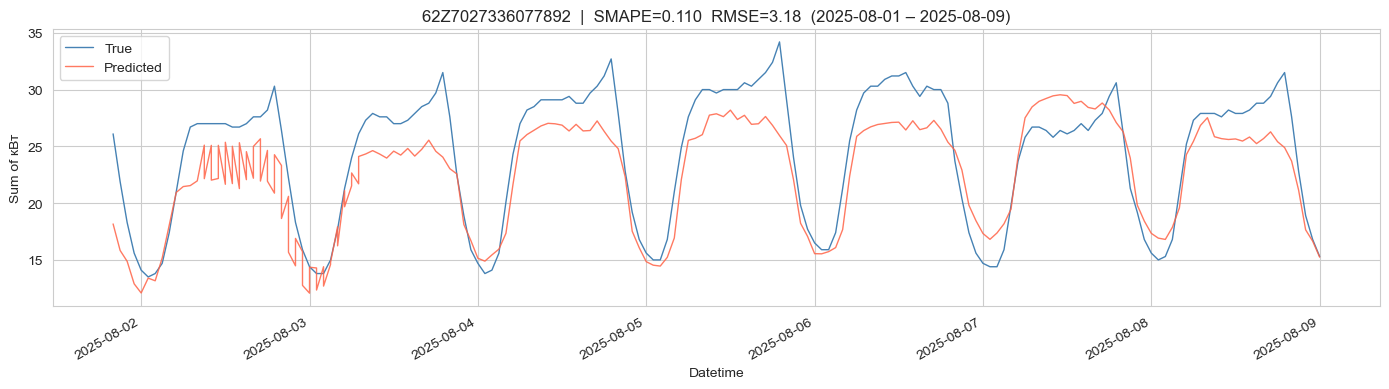

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    """
    Plot true vs predicted кВт for one EiC location.

    Parameters
    ----------
    eval_df  : val_eval or test_eval
    eic_code : value of GROUP_COL ("EIC-код_cat") to display
    start_dt : optional start datetime (str or Timestamp)
    end_dt   : optional end datetime   (str or Timestamp)
    """
    df = eval_df.merge(
        train_val_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")

    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],   label="True",      linewidth=1,    color="steelblue")
    ax.plot(df["datetime"], df["pred"],  label="Predicted", linewidth=1,    color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  SMAPE={smape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} – {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

# Usage examples:
# plot_forecast(val_eval,  eic_code="<code>")
plot_forecast(test_eval, eic_code="62Z7027336077892", start_dt="2025-07-30", end_dt="2025-08-09")

In [21]:
# ── Recursive 6-month forecast on test2 ──────────────────────────────────────
# No ground-truth y → feed predicted values back as encoder context each step.
from tqdm.auto import tqdm
import warnings, logging

labelled_data   = train_val_data[train_val_data["time_idx"] <= test_cutoff].copy()
test2_futr_data = train_val_data[train_val_data["time_idx"] > test_cutoff].copy()

test2_start = int(test2_futr_data["time_idx"].min())
test2_end   = int(test2_futr_data["time_idx"].max())
n_steps     = int(np.ceil((test2_end - test2_start + 1) / MAX_PREDICTION_LENGTH))

# Seed context: only the last MAX_ENCODER_LENGTH rows per group — the encoder
# never looks further back, so carrying the full history wastes memory.
current_context = (
    labelled_data
    .sort_values([GROUP_COL, "time_idx"])
    .groupby(GROUP_COL, sort=False)
    .tail(MAX_ENCODER_LENGTH)
    .reset_index(drop=True)
)
all_step_preds = []

with tqdm(total=n_steps, desc="Recursive forecast", unit="step") as pbar:
    for step_i in range(n_steps):
        window_start = test2_start + step_i * MAX_PREDICTION_LENGTH
        window_end   = min(window_start + MAX_PREDICTION_LENGTH - 1, test2_end)

        window_futr = test2_futr_data[
            (test2_futr_data["time_idx"] >= window_start) &
            (test2_futr_data["time_idx"] <= window_end)
        ].copy()

        if window_futr.empty:
            break

        # combined is always small: MAX_ENCODER_LENGTH + MAX_PREDICTION_LENGTH rows/group
        combined = (
            pd.concat([current_context, window_futr], ignore_index=True)
            .sort_values([GROUP_COL, "time_idx"])
            .reset_index(drop=True)
        )
        try:
            ds = TimeSeriesDataSet.from_dataset(
                training, combined, predict=True, stop_randomization=True,
            )
            loader = ds.to_dataloader(
                train=False, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, pin_memory=True,
            )
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                logging.disable(logging.CRITICAL)
                result = best_tft.predict(
                    loader, return_index=True,
                    trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
                )
                logging.disable(logging.NOTSET)
            pred_tensor = result[0].cpu().numpy()

            step_records = []
            for i, (_, idx_row) in enumerate(result[2].iterrows()):
                for s in range(window_end - window_start + 1):
                    step_records.append({
                        GROUP_COL:  idx_row[GROUP_COL],
                        "time_idx": idx_row["time_idx"] + 1 + s,  # +1: idx_row["time_idx"] is last encoder step
                        "pred":     pred_tensor[i, s],
                    })
            step_df = pd.DataFrame(step_records)
            all_step_preds.append(step_df)

            # Replace placeholder y with predictions so next step's encoder sees them
            window_futr = window_futr.drop(columns=[Y_COL]).merge(
                step_df.rename(columns={"pred": Y_COL})[[GROUP_COL, "time_idx", Y_COL]],
                on=[GROUP_COL, "time_idx"], how="left",
            )
            window_futr[Y_COL] = window_futr[Y_COL].astype("float32")

            # Safety: fill any residual NaNs from merge mismatches
            if window_futr[Y_COL].isna().any():
                window_futr[Y_COL] = window_futr[Y_COL].interpolate(method="linear").ffill().bfill()

            # Roll the context window forward: keep only the tail the encoder needs
            current_context = (
                pd.concat([current_context, window_futr], ignore_index=True)
                .sort_values([GROUP_COL, "time_idx"])
                .groupby(GROUP_COL, sort=False)
                .tail(MAX_ENCODER_LENGTH)
                .reset_index(drop=True)
            )
            pbar.update(1)
            pbar.set_postfix(time_idx=f"{window_start}-{window_end}")
        except:
            pbar.update(1)
            pbar.set_postfix(time_idx=f"{window_start}-{window_end}")

# Assemble and save
test2_predictions = (
    pd.concat(all_step_preds, ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
    .rename(columns={"pred": Y_COL})
)
test2_predictions = test2_predictions.merge(
    test2_futr_data[[GROUP_COL, "time_idx", "datetime"]],
    on=[GROUP_COL, "time_idx"], how="left",
)

import os
os.makedirs("predictions", exist_ok=True)
test2_predictions.to_parquet("predictions/tft_6month.parquet", index=False)
print(f"Saved {test2_predictions.shape[0]} rows to predictions/tft_6month.parquet")
test2_predictions

Recursive forecast:   0%|          | 0/142 [00:00<?, ?step/s]

Saved 2015497 rows to predictions/tft_6month.parquet


,EIC-код_cat,time_idx,Sum of кВт,datetime
0,62Z0008583037334,10275,18.160002,2025-09-01 00:00:00
1,62Z0008583037334,10276,17.352247,2025-09-01 01:00:00
2,62Z0008583037334,10277,16.250654,2025-09-01 02:00:00
3,62Z0008583037334,10278,15.627855,2025-09-01 03:00:00
4,62Z0008583037334,10279,16.154772,2025-09-01 04:00:00
...,...,...,...,...
2015492,62Z9997819406173,15345,17.984188,2026-03-31 06:00:00
2015493,62Z9997819406173,15346,19.995495,2026-03-31 07:00:00
2015494,62Z9997819406173,15347,20.006643,2026-03-31 08:00:00
2015495,62Z9997819406173,15348,20.771374,2026-03-31 09:00:00


In [26]:
import pandas as pd

# Use your predefined dataframe
df = test2_predictions

unique_eics = sorted(df["EIC-код_cat"].unique())
chunk_size = 110
index_records = []

with pd.ExcelWriter("forecast_data.xlsx", engine="openpyxl") as writer:

    # Build index records
    for i in range(0, len(unique_eics), chunk_size):
        chunk_eics = unique_eics[i:i + chunk_size]
        sheet_name = f"EIC {i+1}–{min(i+chunk_size, len(unique_eics))}"

        for eic in chunk_eics:
            index_records.append({
                "EIC-код_cat": eic,
                "Sheet": sheet_name
            })

    # Write index sheet
    index_df = pd.DataFrame(index_records)
    index_df.to_excel(writer, sheet_name="Index", index=False)

    # Write data sheets
    for i in range(0, len(unique_eics), chunk_size):
        chunk_eics = unique_eics[i:i + chunk_size]
        sheet_name = f"EIC {i+1}–{min(i+chunk_size, len(unique_eics))}"

        chunk_df = df[df["EIC-код_cat"].isin(chunk_eics)]
        chunk_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(
    f"Done. {len(unique_eics)} unique EIC values across "
    f"{(len(unique_eics) - 1)//chunk_size + 1} sheets."
)

Done. 397 unique EIC values across 4 sheets.
